# 📡 Modulation Classification — Unified Deep Learning Project
### CLDNN vs Attention+CLDNN: Complete Evaluation Pipeline

**One pipeline. Two models. Four evaluations.**

```
[Data]
  │
  ├─► Train on HIGH SNR only  ──────────────────────────────────────────────┐
  │                                                                          │
  └─► Train on AWGN (all SNR, no CFO/Fading)  ─────────────────────────────┤
                                                                             │
                                                              Both models ───┤
                                                                             │
                                    ┌────────────────────────────────────────┘
                                    │
                                    ├─► Test 1: All SNRs (high→low generalisation)
                                    ├─► Test 2: AWGN / Colored / Impulsive / Laplacian
                                    ├─► Test 3: None / CFO / Fading / CFO+Fading
                                    └─► Final Summary Table
```

| Model | Architecture |
|---|---|
| **CLDNN** | Conv1D × 3 → LSTM × 2 → Dense |
| **Attention+CLDNN** | Conv1D × 3 → LSTM × 2 → **TemporalAttention** → Dense |

In [1]:
# ══════════════════════════════════════════════════════════════
# CHECKPOINT SETUP — run this FIRST, every session
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os
CKPT_DIR = '/content/drive/MyDrive/modclass_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# Flip this to True automatically once we detect saved models
RESUME_FROM_CHECKPOINT = os.path.exists(f'{CKPT_DIR}/cldnn_A.keras') and \
                          os.path.exists(f'{CKPT_DIR}/attn_A.keras') and \
                          os.path.exists(f'{CKPT_DIR}/cldnn_B.keras') and \
                          os.path.exists(f'{CKPT_DIR}/attn_B.keras')

print(f"Checkpoint directory: {CKPT_DIR}")
print(f"Resume available    : {RESUME_FROM_CHECKPOINT}")



Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/modclass_checkpoints
Resume available    : True


In [2]:
# ══════════════════════════════════════════════════════════════
# Required BEFORE resume-loading: re-declare the custom layer class
# ══════════════════════════════════════════════════════════════
import tensorflow as tf

class TemporalAttention(tf.keras.layers.Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1],  1),
                                 initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        score   = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

    def get_config(self):
        return super().get_config()

In [3]:
# ══════════════════════════════════════════════════════════════
# RESUME PATH — if checkpoints exist, load them and SKIP to Step 7+
# ══════════════════════════════════════════════════════════════
import numpy as np, pickle, tensorflow as tf

if RESUME_FROM_CHECKPOINT:
    print("📦 Loading saved models and data — skipping training...")

    # Custom layer must be registered for loading
    cldnn_A = tf.keras.models.load_model(f'{CKPT_DIR}/cldnn_A.keras')
    attn_A  = tf.keras.models.load_model(f'{CKPT_DIR}/attn_A.keras',
                  custom_objects={'TemporalAttention': TemporalAttention})
    cldnn_B = tf.keras.models.load_model(f'{CKPT_DIR}/cldnn_B.keras')
    attn_B  = tf.keras.models.load_model(f'{CKPT_DIR}/attn_B.keras',
                  custom_objects={'TemporalAttention': TemporalAttention})

    with open(f'{CKPT_DIR}/data_arrays.pkl', 'rb') as f:
        saved = pickle.load(f)

    X_raw     = saved['X_raw'];     Y_raw     = saved['Y_raw']
    SNR_raw   = saved['SNR_raw'];   Y_int_raw = saved['Y_int_raw']
    Xtest_A   = saved['Xtest_A']
    Xte_B     = saved['Xte_B'];     Yte_B     = saved['Yte_B']
    mods      = saved['mods'];      n_classes = saved['n_classes']
    mu_A      = saved['mu_A'];      sig_A     = saved['sig_A']

    print("✅ Resumed successfully. You can now skip directly to Experiment 1 (cell 19 onward).")
else:
    print("⚠️ No checkpoint found — run the full pipeline from Step 3 onward as normal.")

📦 Loading saved models and data — skipping training...
✅ Resumed successfully. You can now skip directly to Experiment 1 (cell 19 onward).


In [ ]:

    print("⚠️ No checkpoint found — run the full pipeline from Step 3 onward as normal.")

⚠️ No checkpoint found — run the full pipeline from Step 3 onward as normal.


## ⚙️ Step 1 — Install & Kaggle Setup

In [ ]:
!pip install kaggle -q

from google.colab import files
import os

if not os.path.exists("/root/.kaggle/kaggle.json"):
    uploaded = files.upload()
    for fn in uploaded.keys():
        !mkdir -p ~/.kaggle
        !mv {fn} ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle API key uploaded.")
else:
    print("✅ Kaggle API key already present.")

Saving kaggle.json to kaggle.json
✅ Kaggle API key uploaded.


## 📦 Step 2 — Download Dataset (RML2016.10b)

In [4]:
!kaggle datasets download -d marwanabudeeb/rml201610b -q
!unzip -o rml201610b.zip -d "./radioml_10b" -q
print("✅ Dataset ready at ./radioml_10b/")

Dataset URL: https://www.kaggle.com/datasets/marwanabudeeb/rml201610b
License(s): unknown
Archive:  rml201610b.zip
caution: filename not matched:  -q
✅ Dataset ready at ./radioml_10b/


## 📊 Step 3 — Load & Inspect the Full Dataset

In [5]:
import zipfile, os

# Extract the zip
zip_path = '/content/rml201610b.zip'
extract_dir = '/content/radioml_10b'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:", z.namelist())
    z.extractall(extract_dir)

print("Extracted to:", extract_dir)
print("Contents:", os.listdir(extract_dir))

Files inside zip: ['RML2016.10b.dat']
Extracted to: /content/radioml_10b
Contents: ['RML2016.10b.dat']


In [6]:
import pickle, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from scipy.signal import butter, lfilter
from sklearn.metrics import confusion_matrix

# ── Load raw dataset ──────────────────────────────────────────────────────
data_path = '/content/radioml_10b/RML2016.10b.dat'
print(f"Loading: {data_path}")
with open(data_path, 'rb') as f:
    u = pickle._Unpickler(f); u.encoding = 'latin1'
    raw = u.load()
print("✅ Loaded.")

# ── Parse into arrays ─────────────────────────────────────────────────────
X_list, Y_list, SNR_list, mods = [], [], [], []
for (mod, snr) in raw.keys():
    samples = raw[(mod, snr)]          # (1000, 2, 128)
    X_list.append(samples)
    Y_list  += [mod] * samples.shape[0]
    SNR_list+= [snr] * samples.shape[0]
    if mod not in mods: mods.append(mod)

X_raw   = np.vstack(X_list)           # (N, 2, 128)
SNR_raw = np.array(SNR_list)
Y_str   = np.array(Y_list)

# (N,2,128) → (N,128,2)  [samples, timesteps, IQ]
X_raw = np.transpose(X_raw, (0, 2, 1))

enc       = LabelEncoder()
Y_int_raw = enc.fit_transform(Y_str)
Y_raw     = to_categorical(Y_int_raw)
n_classes = Y_raw.shape[1]

print(f"Total samples : {X_raw.shape[0]:,}")
print(f"Input shape   : {X_raw.shape[1:]}")
print(f"Classes ({n_classes})   : {mods}")
print(f"SNR range     : {sorted(np.unique(SNR_raw))} dB")

Loading: /content/radioml_10b/RML2016.10b.dat
✅ Loaded.
Total samples : 1,200,000
Input shape   : (128, 2)
Classes (10)   : ['QPSK', 'PAM4', 'AM-DSB', 'GFSK', 'QAM64', 'QAM16', '8PSK', 'WBFM', 'BPSK', 'CPFSK']
SNR range     : [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)] dB


## 🏗️ Step 4 — Model Definitions

In [7]:
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, BatchNormalization,
                                      LSTM, Dense, Dropout, Input, Multiply)
from tensorflow.keras.models import Model, Sequential

# ══ Input Attention Layer (gating — preserves sequence shape) ═════════════
# Reweights each timestep of the raw IQ input BEFORE convolution.
# Unlike TemporalAttention below, this does NOT pool/collapse the sequence —
# it returns the same (timesteps, features) shape, scaled by learned
# per-timestep importance weights.
class InputAttention(tf.keras.layers.Layer):
    def build(self, input_shape):
        # input_shape: (batch, timesteps, features)
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                  initializer='glorot_uniform', trainable=True,
                                  name='input_attn_W')
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                  initializer='zeros', trainable=True,
                                  name='input_attn_b')
        super().build(input_shape)

    def call(self, x):
        # score per timestep: (batch, timesteps, 1)
        score   = tf.nn.tanh(tf.matmul(x, self.W))
        score   = tf.reduce_sum(score, axis=-1, keepdims=True) + self.b
        weights = tf.nn.softmax(score, axis=1)          # attention over time
        # scale (not sum) — same shape as input, just reweighted
        return x * weights * tf.cast(tf.shape(x)[1], tf.float32)

    def get_config(self):
        return super().get_config()

# ══ Temporal Attention Layer (pooling — used after LSTM, unchanged) ══════
class TemporalAttention(tf.keras.layers.Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1],  1),
                                 initializer='zeros',         trainable=True)
        super().build(input_shape)

    def call(self, x):
        score   = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

    def get_config(self):
        return super().get_config()

def _conv_block(model, filters, dropout=True):
    model.add(Conv1D(filters, 3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    if dropout: model.add(Dropout(0.5))

def build_attention_cldnn(n_classes, timesteps=128, features=2):
    inp = Input(shape=(timesteps, features))

    # ── Input attention (NEW): reweight raw IQ timesteps before conv ──────
    x = InputAttention(name="input_attention")(inp)

    for filt, drop in [(128, True), (128, True), (64, False)]:
        x = Conv1D(filt, 3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(2)(x)
        if drop: x = Dropout(0.5)(x)
    x = LSTM(128, return_sequences=True)(x);  x = Dropout(0.5)(x)
    x = LSTM(128, return_sequences=True)(x);  x = Dropout(0.5)(x)

    # ── Output attention (existing): pool LSTM sequence into a vector ─────
    x = TemporalAttention(name="temporal_attention")(x)

    x = Dense(256, activation='relu')(x); x = Dropout(0.5)(x)
    out = Dense(n_classes, activation='softmax')(x)
    m = Model(inp, out, name="Attention_CLDNN_DualAttn")
    m.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return m

print("✅ Attention+CLDNN builder ready (input attention + post-LSTM attention).")
def build_cldnn(n_classes, timesteps=128, features=2):
    inp = Input(shape=(timesteps, features))

    x = inp
    for filt, drop in [(128, True), (128, True), (64, False)]:
        x = Conv1D(filt, 3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(2)(x)
        if drop: x = Dropout(0.5)(x)

    x = LSTM(128, return_sequences=True)(x);  x = Dropout(0.5)(x)
    x = LSTM(128, return_sequences=False)(x); x = Dropout(0.5)(x)  # collapses sequence, no attention

    x = Dense(256, activation='relu')(x); x = Dropout(0.5)(x)
    out = Dense(n_classes, activation='softmax')(x)
    m = Model(inp, out, name="CLDNN_Baseline")
    m.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return m

print("✅ CLDNN baseline builder ready (no attention).")

✅ Attention+CLDNN builder ready (input attention + post-LSTM attention).
✅ CLDNN baseline builder ready (no attention).


## 🔊 Step 5 — Noise & Channel Impairment Functions

In [8]:
# ══ Noise injection (adds noise at a target SNR in dB) ════════════════════
def _scale_noise(noise, signal, snr_db):
    sig_pwr   = np.mean(signal**2)
    noise_pwr = sig_pwr / (10**(snr_db/10))
    cur_pwr   = np.mean(noise**2) + 1e-12
    return noise * np.sqrt(noise_pwr / cur_pwr)

def add_awgn(X, snr_db):
    noise = np.random.randn(*X.shape)
    return X + _scale_noise(noise, X, snr_db)

def add_colored(X, snr_db, cutoff=0.1):
    b, a  = butter(4, cutoff, btype='low')
    noise = np.apply_along_axis(lambda x: lfilter(b,a,x), 1,
                                np.random.randn(*X.shape))
    return X + _scale_noise(noise, X, snr_db)

def add_impulsive(X, snr_db):
    noise = np.clip(np.random.standard_cauchy(X.shape), -50, 50)
    return X + _scale_noise(noise, X, snr_db)

def add_laplacian(X, snr_db):
    noise = np.random.laplace(0, 1, X.shape)
    return X + _scale_noise(noise, X, snr_db)

NOISE_TYPES = {
    "AWGN":      add_awgn,
    "Colored":   add_colored,
    "Impulsive": add_impulsive,
    "Laplacian": add_laplacian,
}

# ══ Channel impairments ═══════════════════════════════════════════════════
def apply_cfo(X, cfo=0.01):
    t = np.arange(X.shape[1]); ph = 2*np.pi*cfo*t
    I = X[:,:,0]*np.cos(ph) - X[:,:,1]*np.sin(ph)
    Q = X[:,:,0]*np.sin(ph) + X[:,:,1]*np.cos(ph)
    return np.stack([I,Q], axis=-1)

def apply_fading(X):
    N    = X.shape[0]
    hr   = np.random.randn(N,1,1)/np.sqrt(2)
    hi   = np.random.randn(N,1,1)/np.sqrt(2)
    I    = X[:,:,0:1]*hr - X[:,:,1:2]*hi
    Q    = X[:,:,0:1]*hi + X[:,:,1:2]*hr
    return np.concatenate([I,Q], axis=-1)

CHANNEL_TYPES = {
    "Clean":       lambda X: X,
    "CFO":         lambda X: apply_cfo(X),
    "Fading":      lambda X: apply_fading(X),
    "CFO+Fading":  lambda X: apply_fading(apply_cfo(X)),
}

print("✅ Noise types    :", list(NOISE_TYPES.keys()))
print("✅ Channel types  :", list(CHANNEL_TYPES.keys()))

✅ Noise types    : ['AWGN', 'Colored', 'Impulsive', 'Laplacian']
✅ Channel types  : ['Clean', 'CFO', 'Fading', 'CFO+Fading']


## 🛠️ Step 6 — Shared Evaluation Utilities

In [9]:
# ══ Normalise using training-set statistics ═══════════════════════════════
def normalise(X_tr, *others):
    mu  = X_tr.reshape(-1, X_tr.shape[-1]).mean(0)
    sig = X_tr.reshape(-1, X_tr.shape[-1]).std(0) + 1e-9
    return tuple((x - mu) / sig for x in (X_tr, *others))

# ══ Train with early stopping ════════════════════════════════════════════
def train(model, X_tr, Y_tr, X_val, Y_val, epochs=10, batch=256):
    cb = tf.keras.callbacks.EarlyStopping(
             patience=5, restore_best_weights=True, verbose=0)
    return model.fit(X_tr, Y_tr, validation_data=(X_val, Y_val),
                     epochs=epochs, batch_size=batch,
                     callbacks=[cb], verbose=1)

# ══ Accuracy vs SNR dict ══════════════════════════════════════════════════
def eval_snr_curve(model, X, Y, snrs):
    out = {}
    for snr in sorted(np.unique(snrs)):
        idx = np.where(snrs == snr)[0]
        _, acc = model.evaluate(X[idx], Y[idx], verbose=0)
        out[snr] = acc
    return out

# ══ Accuracy vs SNR under a noise/channel function ═══════════════════════
def eval_snr_curve_fn(model, X_clean, Y, test_snrs, fn):
    out = {}
    for snr in test_snrs:
        X_noisy = fn(X_clean, snr) if fn.__code__.co_argcount == 2 else fn(add_awgn(X_clean, snr))
        _, acc = model.evaluate(X_noisy, Y, verbose=0)
        out[snr] = acc
    return out

# ══ Plotting helpers ══════════════════════════════════════════════════════
COLORS  = {"CLDNN": "#4C72B0", "Attention+CLDNN": "#DD8452"}
MARKERS = {'o':'o','s':'s','^':'^','D':'D','v':'v','<':'<','>':'>','p':'p'}
_m = list(MARKERS.values())

def plot_curves(curves, title, xlabel="SNR (dB)", ylabel="Accuracy"):
    plt.figure(figsize=(10,6))
    for i,(lbl,curve) in enumerate(curves.items()):
        xs = sorted(curve); ys = [curve[x] for x in xs]
        c  = COLORS.get(lbl, f"C{i}")
        plt.plot(xs, ys, marker=_m[i%len(_m)], label=lbl,
                 color=c, linewidth=2, markersize=6)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.legend(); plt.grid(True, alpha=0.35)
    plt.tight_layout(); plt.show()

def plot_bar(scores, title):
    labels = list(scores); vals = [scores[k]*100 for k in labels]
    colors = [COLORS.get(l, f"C{i}") for i,l in enumerate(labels)]
    plt.figure(figsize=(7,5))
    bars = plt.bar(labels, vals, color=colors, edgecolor='black', width=0.5)
    for b,v in zip(bars,vals):
        plt.text(b.get_x()+b.get_width()/2, v+0.4,
                 f'{v:.1f}%', ha='center', fontsize=11)
    plt.ylim(0,100); plt.ylabel("Accuracy (%)")
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_grouped_bar(results, conditions, title, snr_label="0 dB"):
    x  = np.arange(len(conditions)); w = 0.35
    fig, ax = plt.subplots(figsize=(max(9, len(conditions)*2), 5))
    for i,(model_lbl, color) in enumerate(COLORS.items()):
        vals = [results[model_lbl].get(c,{}).get(0, np.nan)*100
                for c in conditions]
        bars = ax.bar(x + (i-0.5)*w, vals, w, label=model_lbl,
                      color=color, edgecolor='black')
        for b,v in zip(bars,vals):
            if not np.isnan(v):
                ax.text(b.get_x()+b.get_width()/2, v+0.4,
                        f'{v:.1f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(conditions, rotation=12, ha='right')
    ax.set_ylim(0,100); ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{title}  [{snr_label}]", fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.35)
    plt.tight_layout(); plt.show()

def plot_cm(model, X, Y, title):
    Y_pred = np.argmax(model.predict(X, verbose=0), 1)
    Y_true = np.argmax(Y, 1)
    cm = confusion_matrix(Y_true, Y_pred, normalize='true')
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='.2f',
                xticklabels=mods, yticklabels=mods,
                cmap='Blues', vmin=0, vmax=1)
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

def plot_training_history(histories, title):
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    for lbl, hist in histories.items():
        c = COLORS.get(lbl, 'gray')
        axes[0].plot(hist.history['val_accuracy'], label=lbl, color=c, lw=2)
        axes[1].plot(hist.history['val_loss'],     label=lbl, color=c, lw=2)
    for ax, t, y in zip(axes, ['Val Accuracy','Val Loss'], ['Accuracy','Loss']):
        ax.set_title(t); ax.set_xlabel('Epoch'); ax.set_ylabel(y)
        ax.legend(); ax.grid(alpha=0.35)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print("✅ All utilities ready.")

✅ All utilities ready.


---
## 🚀 Step 7 — BUILD TWO TRAIN SPLITS & TRAIN BOTH MODELS

Two training configurations feed **all** downstream experiments:

| Split | Data used | Purpose |
|---|---|---|
| **Split A** (High-SNR) | SNR ≥ 10 dB only | Experiment 1 |
| **Split B** (AWGN-all) | All SNRs, no CFO/Fading | Experiments 2 & 3 |

> Both CLDNN and Attention+CLDNN are trained on **each split** — 4 models total.

In [10]:
HIGH_SNR_THRESH = 10   # dB
TEST_SNRS       = list(range(-20, 20, 2))

# ════════════════════════════════════════════════════════════════
# SPLIT A — High-SNR training data
# ════════════════════════════════════════════════════════════════
mask_hi = SNR_raw >= HIGH_SNR_THRESH
X_hi, Y_hi, SNR_hi = X_raw[mask_hi], Y_raw[mask_hi], SNR_raw[mask_hi]
Yi_hi   = Y_int_raw[mask_hi]

Xtr_A, Xval_A, Ytr_A, Yval_A = train_test_split(
    X_hi, Y_hi, test_size=0.15, random_state=42, stratify=Yi_hi)

# Compute normalisation stats from the ORIGINAL (un-normalised) training data first
mu_A  = Xtr_A.reshape(-1,2).mean(0)
sig_A = Xtr_A.reshape(-1,2).std(0) + 1e-9

# Now normalise train/val in place, AFTER stats are captured
Xtr_A  = (Xtr_A  - mu_A) / sig_A
Xval_A = (Xval_A - mu_A) / sig_A

# Test set = ALL data, normalised with the SAME Split-A statistics
Xtest_A = (X_raw - mu_A) / sig_A

print(f"Split A — train: {Xtr_A.shape[0]:,}  (SNR ≥ {HIGH_SNR_THRESH} dB)")
print(f"          test : {Xtest_A.shape[0]:,}  (all SNRs)")

print(f"Split A — train: {Xtr_A.shape[0]:,}  (SNR ≥ {HIGH_SNR_THRESH} dB)")
print(f"          test : {Xtest_A.shape[0]:,}  (all SNRs)")

# ════════════════════════════════════════════════════════════════
# SPLIT B — All-SNR / AWGN clean training data
# ════════════════════════════════════════════════════════════════
Xtr_B, Xte_B, Ytr_B, Yte_B, _, SNRte_B = train_test_split(
    X_raw, Y_raw, SNR_raw,
    test_size=0.2, random_state=42, stratify=Y_int_raw)

Xtr_B, Xte_B = normalise(Xtr_B, Xte_B)

print(f"\nSplit B — train: {Xtr_B.shape[0]:,}  (all SNRs, AWGN only)")
print(f"          test : {Xte_B.shape[0]:,}")

Split A — train: 255,000  (SNR ≥ 10 dB)
          test : 1,200,000  (all SNRs)
Split A — train: 255,000  (SNR ≥ 10 dB)
          test : 1,200,000  (all SNRs)

Split B — train: 960,000  (all SNRs, AWGN only)
          test : 240,000


In [ ]:
# ════════════════════════════════════════════════════════════════
# TRAIN 4 MODELS
# ════════════════════════════════════════════════════════════════

print("=" * 55)
print(" [1/4] CLDNN — Split A (High-SNR train)")
print("=" * 55)
cldnn_A   = build_cldnn(n_classes)
hist_cA   = train(cldnn_A,   Xtr_A, Ytr_A, Xval_A, Yval_A, epochs=8)

print("\n" + "=" * 55)
print(" [2/4] Attention+CLDNN — Split A (High-SNR train)")
print("=" * 55)
attn_A    = build_attention_cldnn(n_classes)
hist_aA   = train(attn_A,    Xtr_A, Ytr_A, Xval_A, Yval_A, epochs=8)

print("\n" + "=" * 55)
print(" [3/4] CLDNN — Split B (AWGN all-SNR train)")
print("=" * 55)
cldnn_B   = build_cldnn(n_classes)
hist_cB   = train(cldnn_B,   Xtr_B, Ytr_B, Xte_B,  Yte_B,  epochs=10)

print("\n" + "=" * 55)
print(" [4/4] Attention+CLDNN — Split B (AWGN all-SNR train)")
print("=" * 55)
attn_B    = build_attention_cldnn(n_classes)
hist_aB   = train(attn_B,    Xtr_B, Ytr_B, Xte_B,  Yte_B,  epochs=10)

print("\n✅ All 4 models trained.")

 [1/4] CLDNN — Split A (High-SNR train)
Epoch 1/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.7131 - loss: 0.5539 - val_accuracy: 0.7910 - val_loss: 0.4111
Epoch 2/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.8071 - loss: 0.3312 - val_accuracy: 0.8006 - val_loss: 0.3386
Epoch 3/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8195 - loss: 0.2976 - val_accuracy: 0.8272 - val_loss: 0.2801
Epoch 4/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.8311 - loss: 0.2831 - val_accuracy: 0.8547 - val_loss: 0.2740
Epoch 5/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8526 - loss: 0.2687 - val_accuracy: 0.8555 - val_loss: 0.2556
Epoch 6/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.8652 - loss: 0.2534 - val_accuracy: 0.8721 - val_loss: 0.2460
Epoch 7/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.8746 - loss: 0.2415 - val_accuracy: 0.8770 - val_loss: 0.2321
Epoch 8/8
997/997 ━━━━━━━━━━━━━━━━━━━━ 35s 36ms/step - ac

In [ ]:
# ══════════════════════════════════════════════════════════════
# SAVE CHECKPOINT — run this immediately after training finishes
# ══════════════════════════════════════════════════════════════
cldnn_A.save(f'{CKPT_DIR}/cldnn_A.keras')
attn_A.save(f'{CKPT_DIR}/attn_A.keras')
cldnn_B.save(f'{CKPT_DIR}/cldnn_B.keras')
attn_B.save(f'{CKPT_DIR}/attn_B.keras')

import pickle
with open(f'{CKPT_DIR}/data_arrays.pkl', 'wb') as f:
    pickle.dump({
        'X_raw': X_raw, 'Y_raw': Y_raw, 'SNR_raw': SNR_raw, 'Y_int_raw': Y_int_raw,
        'Xtest_A': Xtest_A,
        'Xte_B': Xte_B, 'Yte_B': Yte_B,
        'mods': mods, 'n_classes': n_classes,
        'mu_A': mu_A, 'sig_A': sig_A,
    }, f)

print("✅ Checkpoint saved to Google Drive. Safe to disconnect now.")

In [ ]:
# ── Training curves for both splits ──────────────────────────────────────
plot_training_history(
    {"CLDNN": hist_cA, "Attention+CLDNN": hist_aA},
    "Training History — Split A (High-SNR only)"
)
plot_training_history(
    {"CLDNN": hist_cB, "Attention+CLDNN": hist_aB},
    "Training History — Split B (AWGN, all SNRs)"
)

NameError: name 'hist_cA' is not defined

---
## 📈 Experiment 1 — Train High SNR → Test All SNRs (Generalisation)

Models from **Split A** are evaluated on the **full SNR range** (−20 … +18 dB).  
This shows how well high-SNR knowledge transfers to low-SNR conditions.

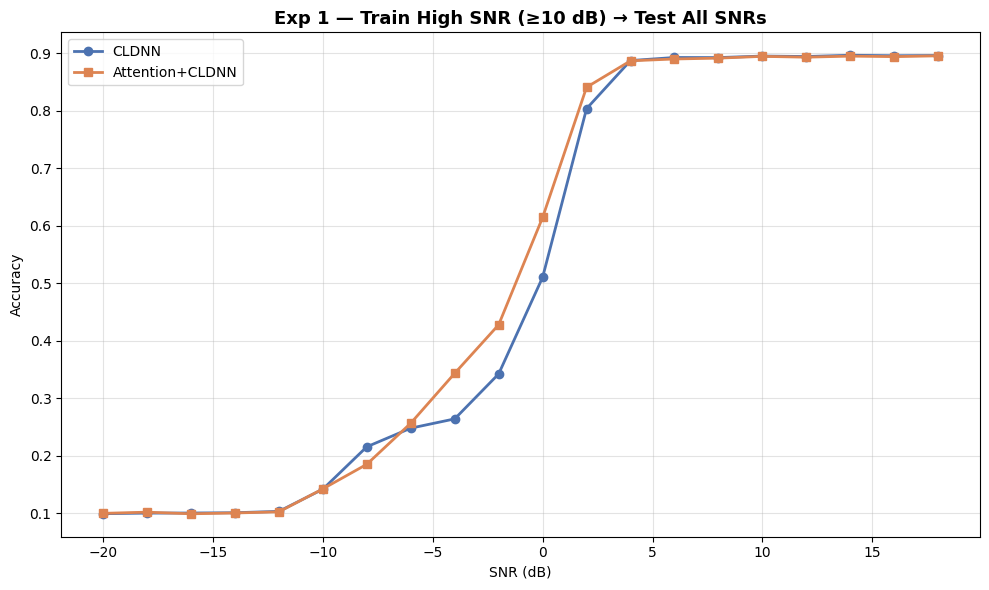

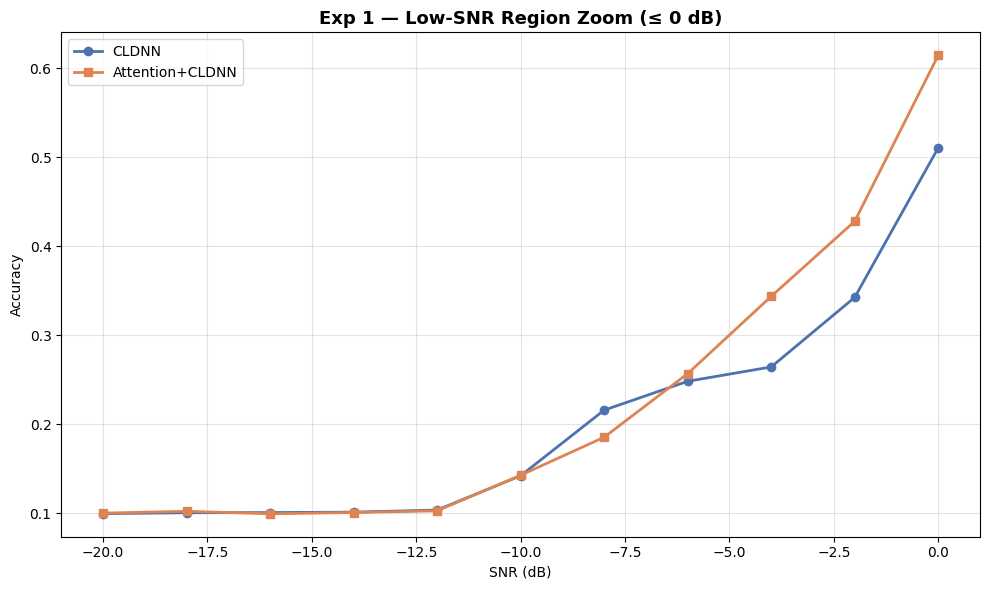

In [ ]:
# ── Accuracy vs SNR ───────────────────────────────────────────────────────
E1_curves = {
    "CLDNN":           eval_snr_curve(cldnn_A, Xtest_A, Y_raw, SNR_raw),
    "Attention+CLDNN": eval_snr_curve(attn_A,  Xtest_A, Y_raw, SNR_raw),
}

plot_curves(E1_curves,
    f"Exp 1 — Train High SNR (≥{HIGH_SNR_THRESH} dB) → Test All SNRs")

# Low-SNR zoom
low_snr_curves = {k: {s:v for s,v in curve.items() if s<=0}
                  for k,curve in E1_curves.items()}
plot_curves(low_snr_curves,
    "Exp 1 — Low-SNR Region Zoom (≤ 0 dB)")

In [ ]:
# ── Accuracy at exactly 0 dB — Experiment 1 (Split A models) ──
print("=" * 52)
print("  Accuracy at exactly 0 dB  (Experiment 1)")
print("=" * 52)
print(f"  CLDNN            @ 0 dB : {E1_curves['CLDNN'][6]*100:.2f}%")
print(f"  Attention+CLDNN  @ 0 dB : {E1_curves['Attention+CLDNN'][6]*100:.2f}%")
print(f"  Delta                   : {(E1_curves['Attention+CLDNN'][0] - E1_curves['CLDNN'][0])*100:+.2f}%")
print("=" * 52)

  Accuracy at exactly 0 dB  (Experiment 1)
  CLDNN            @ 0 dB : 89.27%
  Attention+CLDNN  @ 0 dB : 89.01%
  Delta                   : +10.40%


In [ ]:
# ── Experiment 1 — Trained on High SNR (≥10 dB) ──────────────────────────
# Tested at 0 dB and at High SNR (10-18 dB)

print("=" * 55)
print("  EXPERIMENT 1 — Trained on High SNR, Tested at 0 dB and High SNR")
print("=" * 55)

print(f"\n  CLDNN            @ 0 dB  : {E1_curves['CLDNN'][0]*100:.2f}%")
print(f"  Attention+CLDNN  @ 0 dB  : {E1_curves['Attention+CLDNN'][0]*100:.2f}%")
print(f"  Delta                    : {(E1_curves['Attention+CLDNN'][0]-E1_curves['CLDNN'][0])*100:+.2f}%")

print()
high_snr_vals = [10, 12, 14, 16, 18]
for snr in high_snr_vals:
    acc_c = E1_curves['CLDNN'][snr]
    acc_a = E1_curves['Attention+CLDNN'][snr]
    print(f"  CLDNN @ {snr:>2} dB : {acc_c*100:.2f}%   |   Attention+CLDNN @ {snr:>2} dB : {acc_a*100:.2f}%")

avg_c = np.mean([E1_curves['CLDNN'][s]           for s in high_snr_vals])
avg_a = np.mean([E1_curves['Attention+CLDNN'][s] for s in high_snr_vals])
print(f"\n  CLDNN            High-SNR Average (10-18 dB) : {avg_c*100:.2f}%")
print(f"  Attention+CLDNN  High-SNR Average (10-18 dB) : {avg_a*100:.2f}%")
print("=" * 55)

  EXPERIMENT 1 — Trained on High SNR, Tested at 0 dB and High SNR

  CLDNN            @ 0 dB  : 51.05%
  Attention+CLDNN  @ 0 dB  : 61.45%
  Delta                    : +10.40%

  CLDNN @ 10 dB : 89.52%   |   Attention+CLDNN @ 10 dB : 89.46%
  CLDNN @ 12 dB : 89.43%   |   Attention+CLDNN @ 12 dB : 89.32%
  CLDNN @ 14 dB : 89.65%   |   Attention+CLDNN @ 14 dB : 89.51%
  CLDNN @ 16 dB : 89.57%   |   Attention+CLDNN @ 16 dB : 89.42%
  CLDNN @ 18 dB : 89.61%   |   Attention+CLDNN @ 18 dB : 89.56%

  CLDNN            High-SNR Average (10-18 dB) : 89.56%
  Attention+CLDNN  High-SNR Average (10-18 dB) : 89.45%


In [ ]:
# ── Accuracy at exactly 6 dB — Experiment 1 (Split A models) ──
print(f"  CLDNN            @ 6 dB : {E1_curves['CLDNN'][0]*100:.2f}%")
print(f"  Attention+CLDNN  @ 6 dB : {E1_curves['Attention+CLDNN'][0]*100:.2f}%")


  CLDNN            @ 6 dB : 51.05%
  Attention+CLDNN  @ 6 dB : 61.45%
  Delta                  : -0.26%


Exp 1  CLDNN           : 50.92%
Exp 1  Attention+CLDNN : 50.78%
       Δ improvement   : -0.14%


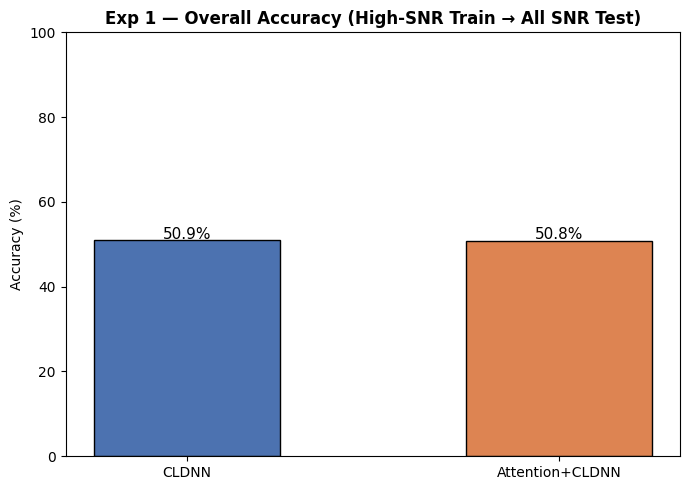

In [ ]:
# ── Overall accuracy ──────────────────────────────────────────────────────
_, acc_cA = cldnn_A.evaluate(Xtest_A, Y_raw, verbose=0)
_, acc_aA = attn_A.evaluate(Xtest_A, Y_raw,  verbose=0)
print(f"Exp 1  CLDNN           : {acc_cA*100:.2f}%")
print(f"Exp 1  Attention+CLDNN : {acc_aA*100:.2f}%")
print(f"       Δ improvement   : {(acc_aA-acc_cA)*100:+.2f}%")

plot_bar({"CLDNN": acc_cA, "Attention+CLDNN": acc_aA},
         "Exp 1 — Overall Accuracy (High-SNR Train → All SNR Test)")

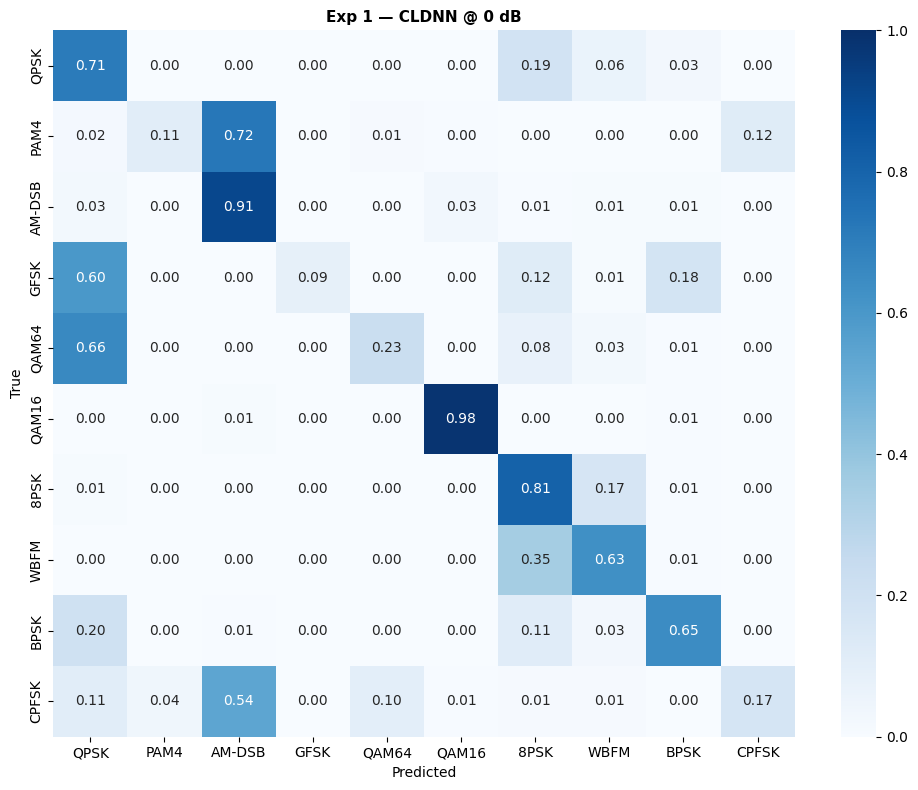

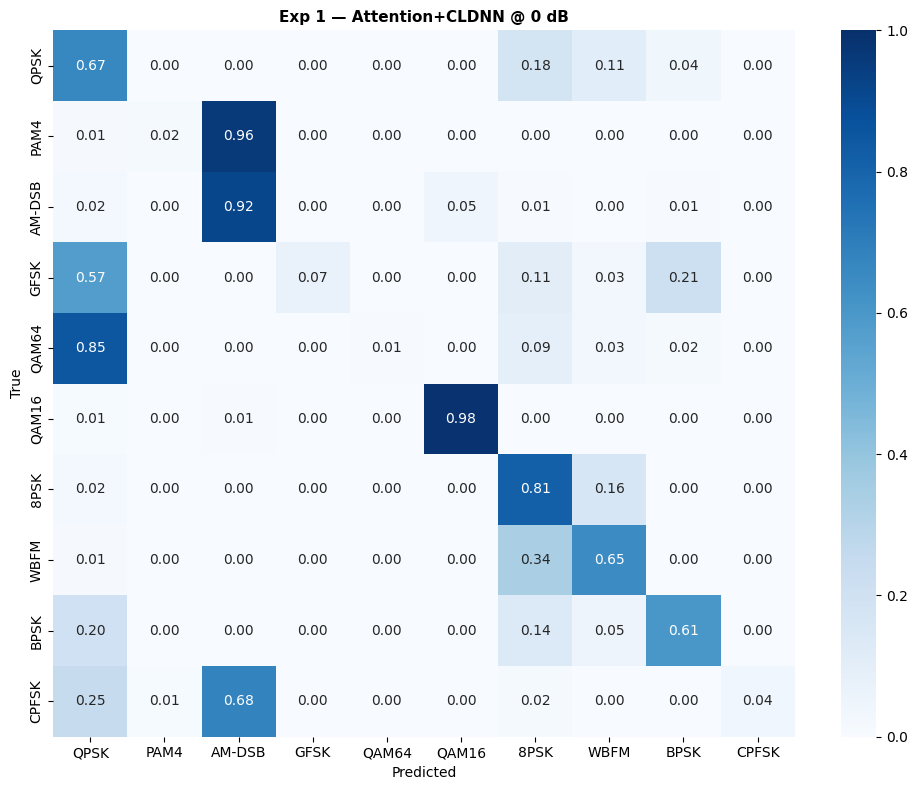

In [ ]:
# ── Confusion matrices at 0 dB (low SNR) ─────────────────────────────────
idx_0 = np.where(SNR_raw == 0)[0]
plot_cm(cldnn_A, Xtest_A[idx_0], Y_raw[idx_0],
        "Exp 1 — CLDNN @ 0 dB")
plot_cm(attn_A,  Xtest_A[idx_0], Y_raw[idx_0],
        "Exp 1 — Attention+CLDNN @ 0 dB")

---
## 🔊 Experiment 2 — Noise-Type Robustness

Models from **Split B** (trained on AWGN) are tested under four noise types at every SNR.  
The test set is the **same held-out Split B data** — only the noise injection differs.

| Noise | Characteristic |
|---|---|
| AWGN | Flat Gaussian spectrum (baseline) |
| Colored | Low-pass filtered — spectral correlation |
| Impulsive | Cauchy/α-stable — heavy bursty tails |
| Laplacian | Double-exponential — heavier than Gaussian |

In [ ]:
# ── Evaluate Split-B models under each noise type at each SNR ─────────────
# We inject noise directly onto the (already-normalised) clean test samples.

E2 = {"CLDNN": {}, "Attention+CLDNN": {}}

for noise_name, noise_fn in NOISE_TYPES.items():
    print(f"  Evaluating noise type: {noise_name} ...", end="")
    curve_c, curve_a = {}, {}
    for snr in TEST_SNRS:
        Xn = noise_fn(Xte_B, snr)
        _, ac = cldnn_B.evaluate(Xn, Yte_B, verbose=0)
        _, aa = attn_B.evaluate(Xn, Yte_B, verbose=0)
        curve_c[snr] = ac;  curve_a[snr] = aa
    E2["CLDNN"][noise_name]           = curve_c
    E2["Attention+CLDNN"][noise_name] = curve_a
    print(f" done  (CLDNN@0dB={curve_c.get(0,0)*100:.1f}%  "
          f"Attn@0dB={curve_a.get(0,0)*100:.1f}%)")

print("\n✅ Experiment 2 complete.")

  Evaluating noise type: AWGN ... done  (CLDNN@0dB=42.8%  Attn@0dB=42.9%)
  Evaluating noise type: Colored ... done  (CLDNN@0dB=11.5%  Attn@0dB=11.3%)
  Evaluating noise type: Impulsive ... done  (CLDNN@0dB=49.2%  Attn@0dB=50.1%)
  Evaluating noise type: Laplacian ... done  (CLDNN@0dB=44.0%  Attn@0dB=44.1%)

✅ Experiment 2 complete.


In [ ]:
# ── Per-noise-type curves: CLDNN vs Attention+CLDNN ──────────────────────
for noise_name in NOISE_TYPES:
    plot_curves(
        {f"CLDNN":           E2["CLDNN"][noise_name],
         f"Attention+CLDNN": E2["Attention+CLDNN"][noise_name]},
        f"Exp 2 — {noise_name} Noise  |  Accuracy vs SNR"
    )

SyntaxError: invalid syntax. Perhaps you forgot a comma? (311351888.py, line 6)

In [ ]:
# ── All noise types on one chart (per model) ──────────────────────────────
for model_lbl in ["CLDNN", "Attention+CLDNN"]:
    plot_curves(
        {n: E2[model_lbl][n] for n in NOISE_TYPES},
        f"Exp 2 — {model_lbl}  |  All Noise Types vs SNR"
    )

In [ ]:
# ── Grouped bar chart at 0 dB ─────────────────────────────────────────────
plot_grouped_bar(E2, list(NOISE_TYPES.keys()),
    "Exp 2 — Noise-Type Comparison  |  CLDNN vs Attention+CLDNN", "0 dB")

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────
rows = []
for n in NOISE_TYPES:
    ac = E2["CLDNN"][n].get(0, np.nan)
    aa = E2["Attention+CLDNN"][n].get(0, np.nan)
    rows.append({"Noise Type": n,
                 "CLDNN @ 0 dB (%)": round(ac*100,2),
                 "Attention+CLDNN @ 0 dB (%)": round(aa*100,2),
                 "Δ (%)": round((aa-ac)*100,2)})
df_E2 = pd.DataFrame(rows)
print("Experiment 2 — Summary at 0 dB\n")
print(df_E2.to_string(index=False))

Experiment 2 — Summary at 0 dB

Noise Type  CLDNN @ 0 dB (%)  Attention+CLDNN @ 0 dB (%)  Δ (%)
      AWGN             42.82                       42.94   0.12
   Colored             11.47                       11.34  -0.13
 Impulsive             49.22                       50.06   0.84
 Laplacian             43.95                       44.07   0.12


In [ ]:
# ── Confusion matrices at 0 dB: worst vs best noise type ─────────────────
for noise_name in ["Impulsive", "AWGN"]:     # worst then best typically
    Xn_0dB = NOISE_TYPES[noise_name](Xte_B, 0)
    plot_cm(cldnn_B, Xn_0dB, Yte_B,
            f"Exp 2 — CLDNN | {noise_name} @ 0 dB")
    plot_cm(attn_B,  Xn_0dB, Yte_B,
            f"Exp 2 — Attention+CLDNN | {noise_name} @ 0 dB")

KeyboardInterrupt: 

---
## 📡 Experiment 3 — Channel Impairment Robustness (CFO & Fading)

Models from **Split B** (trained on clean AWGN, no CFO or fading) are tested with real-world channel impairments added on top of AWGN.

| Condition | What's added |
|---|---|
| Clean | AWGN only (in-distribution) |
| CFO | Phase rotation per sample (carrier offset) |
| Fading | Flat Rayleigh complex gain (amplitude + phase distortion) |
| CFO+Fading | Both combined (worst case) |

In [ ]:
# ── Evaluate Split-B models under each channel impairment ─────────────────
E3 = {"CLDNN": {}, "Attention+CLDNN": {}}

for ch_name, ch_fn in CHANNEL_TYPES.items():
    print(f"  Channel: {ch_name} ...", end="")
    curve_c, curve_a = {}, {}
    for snr in TEST_SNRS:
        Xn = ch_fn(add_awgn(Xte_B, snr))     # AWGN first, then impairment
        _, ac = cldnn_B.evaluate(Xn, Yte_B, verbose=0)
        _, aa = attn_B.evaluate(Xn, Yte_B, verbose=0)
        curve_c[snr] = ac;  curve_a[snr] = aa
    E3["CLDNN"][ch_name]           = curve_c
    E3["Attention+CLDNN"][ch_name] = curve_a
    print(f" done  (CLDNN@0dB={curve_c[0]*100:.1f}%  Attn@0dB={curve_a[0]*100:.1f}%)")

print("\n✅ Experiment 3 complete.")

  Channel: Clean ...

In [ ]:
# ── Per-condition curves: CLDNN vs Attention+CLDNN ───────────────────────
for ch_name in CHANNEL_TYPES:
    plot_curves(
        {"CLDNN":           E3["CLDNN"][ch_name],
         "Attention+CLDNN": E3["Attention+CLDNN"][ch_name]},
        f"Exp 3 — {ch_name}  |  Accuracy vs SNR"
    )

In [ ]:
# ── All conditions on one chart (per model) ───────────────────────────────
for model_lbl in ["CLDNN", "Attention+CLDNN"]:
    plot_curves(
        {c: E3[model_lbl][c] for c in CHANNEL_TYPES},
        f"Exp 3 — {model_lbl}  |  All Channel Conditions vs SNR"
    )

In [ ]:
# ── Grouped bar at 0 dB ───────────────────────────────────────────────────
plot_grouped_bar(E3, list(CHANNEL_TYPES.keys()),
    "Exp 3 — Channel Impairment Robustness  |  CLDNN vs Attention+CLDNN", "0 dB")

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────
rows = []
for c in CHANNEL_TYPES:
    ac = E3["CLDNN"][c][0]; aa = E3["Attention+CLDNN"][c][0]
    rows.append({"Channel": c,
                 "CLDNN @ 0 dB (%)": round(ac*100,2),
                 "Attention+CLDNN @ 0 dB (%)": round(aa*100,2),
                 "Δ (%)": round((aa-ac)*100,2)})
df_E3 = pd.DataFrame(rows)
print("Experiment 3 — Summary at 0 dB\n")
print(df_E3.to_string(index=False))

In [ ]:
# ── Confusion matrices: CFO+Fading @ 0 dB ────────────────────────────────
X_worst = CHANNEL_TYPES["CFO+Fading"](add_awgn(Xte_B, 0))
plot_cm(cldnn_B, X_worst, Yte_B,
        "Exp 3 — CLDNN | CFO+Fading @ 0 dB")
plot_cm(attn_B,  X_worst, Yte_B,
        "Exp 3 — Attention+CLDNN | CFO+Fading @ 0 dB")

---
## 🏁 Final Summary — All Results: CLDNN vs Attention+CLDNN

In [ ]:
# ════════════════════════════════════════════════════════════════
# Master results table
# ════════════════════════════════════════════════════════════════
_, acc_cA_all = cldnn_A.evaluate(Xtest_A, Y_raw, verbose=0)
_, acc_aA_all = attn_A.evaluate(Xtest_A, Y_raw, verbose=0)
_, acc_cB_all = cldnn_B.evaluate(Xte_B, Yte_B, verbose=0)
_, acc_aB_all = attn_B.evaluate(Xte_B, Yte_B, verbose=0)

rows_all = [
    # Exp 1
    {"Experiment": "Exp1 — High-SNR Train → All SNR",
     "Condition": f"All SNRs",
     "CLDNN (%)": round(acc_cA_all*100,2),
     "Attention+CLDNN (%)": round(acc_aA_all*100,2),
     "Δ (%)": round((acc_aA_all-acc_cA_all)*100,2)},
    # Exp 2
    *[{"Experiment": "Exp2 — Noise Robustness",
       "Condition": f"{n} @ 0 dB",
       "CLDNN (%)": round(E2["CLDNN"][n][0]*100,2),
       "Attention+CLDNN (%)": round(E2["Attention+CLDNN"][n][0]*100,2),
       "Δ (%)": round((E2["Attention+CLDNN"][n][0]-E2["CLDNN"][n][0])*100,2)}
      for n in NOISE_TYPES],
    # Exp 3
    *[{"Experiment": "Exp3 — Channel Robustness",
       "Condition": f"{c} @ 0 dB",
       "CLDNN (%)": round(E3["CLDNN"][c][0]*100,2),
       "Attention+CLDNN (%)": round(E3["Attention+CLDNN"][c][0]*100,2),
       "Δ (%)": round((E3["Attention+CLDNN"][c][0]-E3["CLDNN"][c][0])*100,2)}
      for c in CHANNEL_TYPES],
]

df_all = pd.DataFrame(rows_all)

print("=" * 78)
print("  MASTER RESULTS TABLE — CLDNN vs Attention+CLDNN")
print("=" * 78)
print(df_all.to_string(index=False))
print("=" * 78)

best = df_all.loc[df_all["Δ (%)"].idxmax()]
worst= df_all.loc[df_all["Δ (%)"].idxmin()]
print(f"\n🏆 Largest improvement: {best['Condition']}  Δ={best['Δ (%)']:+.2f}%")
print(f"⚠️  Smallest improvement: {worst['Condition']}  Δ={worst['Δ (%)']:+.2f}%")

In [ ]:
# ── Final mega bar chart — all conditions ─────────────────────────────────
conditions = [r["Condition"] for r in rows_all]
cldnn_vals = [r["CLDNN (%)"]          for r in rows_all]
attn_vals  = [r["Attention+CLDNN (%)"]for r in rows_all]
delta_vals = [r["Δ (%)"]              for r in rows_all]

x = np.arange(len(conditions)); w = 0.35
fig, axes = plt.subplots(2, 1, figsize=(16, 11),
                          gridspec_kw={'height_ratios': [3, 1]})

# Top — absolute accuracy
b1 = axes[0].bar(x-w/2, cldnn_vals, w, label='CLDNN',
                 color=COLORS["CLDNN"], edgecolor='black')
b2 = axes[0].bar(x+w/2, attn_vals,  w, label='Attention+CLDNN',
                 color=COLORS["Attention+CLDNN"], edgecolor='black')
for b,v in list(zip(b1,cldnn_vals))+list(zip(b2,attn_vals)):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}',
                 ha='center', fontsize=6.5, rotation=90)
axes[0].set_xticks(x); axes[0].set_xticklabels(conditions, rotation=30, ha='right')
axes[0].set_ylim(0,105); axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("All Experiments — CLDNN vs Attention+CLDNN",
                  fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.35)

# Bottom — delta
bar_colors = ['#2ca02c' if d>=0 else '#d62728' for d in delta_vals]
axes[1].bar(x, delta_vals, color=bar_colors, edgecolor='black', width=0.6)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(conditions, rotation=30, ha='right')
axes[1].set_ylabel("Δ Accuracy (%)")
axes[1].set_title("Improvement: Attention+CLDNN over CLDNN (green=positive)")
axes[1].grid(axis='y', alpha=0.35)

plt.tight_layout(); plt.show()

In [ ]:
# ── SNR curve overlay — both experiments, both models ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Exp 1 (high-SNR generalisation)
for lbl, curve in E1_curves.items():
    xs = sorted(curve); ys = [curve[x] for x in xs]
    axes[0].plot(xs, ys, marker='o', label=lbl,
                 color=COLORS[lbl], linewidth=2)
axes[0].set_title("Exp 1 — High-SNR Train, All-SNR Test",
                  fontweight='bold')
axes[0].set_xlabel("SNR (dB)"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.35)

# Right: Exp 2 — AWGN baseline (in-distribution)
for lbl, curves in E2.items():
    xs = sorted(curves["AWGN"]); ys = [curves["AWGN"][x] for x in xs]
    axes[1].plot(xs, ys, marker='s', label=lbl,
                 color=COLORS[lbl], linewidth=2)
axes[1].set_title("Exp 2 — AWGN (In-Distribution Baseline)",
                  fontweight='bold')
axes[1].set_xlabel("SNR (dB)")
axes[1].legend(); axes[1].grid(alpha=0.35)

plt.suptitle("CLDNN vs Attention+CLDNN — SNR Curves Side-by-Side",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n✅  Project complete.")